'C:\Users\Abdul' is not recognized as an internal or external command,
operable program or batch file.


C:\Users\Abdul Shaikh
               model   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  
             model   mpg  cyl   disp   hp  drat     wt  qsec  vs  am  gear  \
27    Lotus Europa  30.4    4   95.1  113  3.77  1.513  16.9   1   1     5   
28  Ford Pantera L  15.8    8  351.0  264  4.22  3.170  14.5   0   1     5   
29    Ferrari Dino  19.7    6  145.0  175  3.62  2.770  15.5   0   1     5   
30   Maserati Bora  15.0    8  301.0  335  3.54  3.570  14.6   0   1     5   
31      Volvo 142E  21.4    4  121.0  109

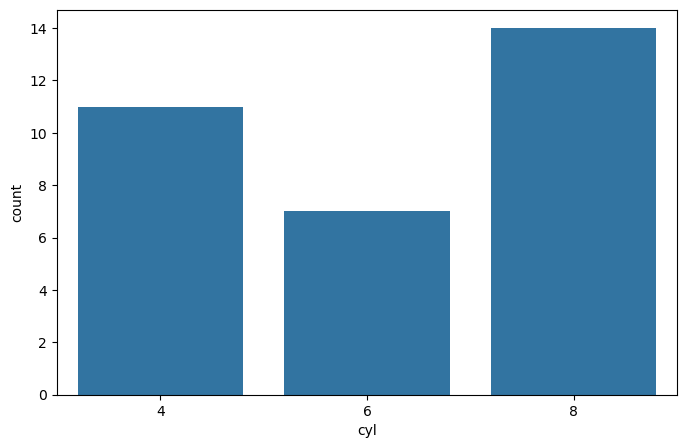

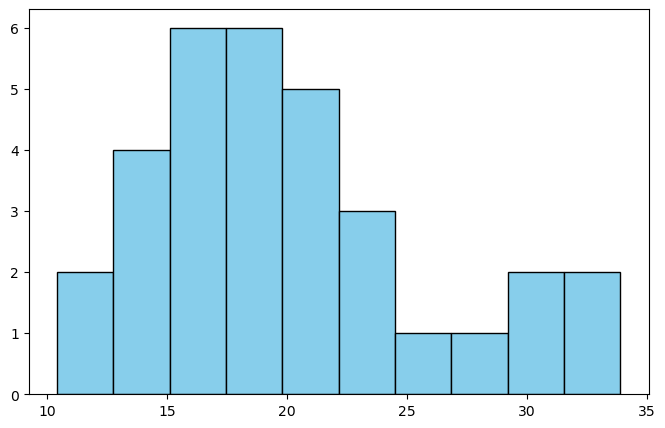

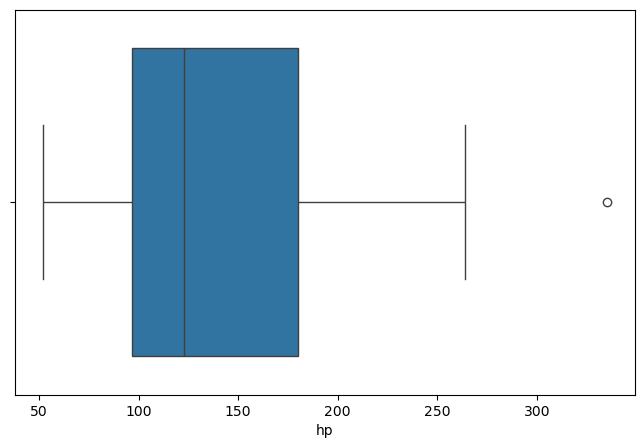

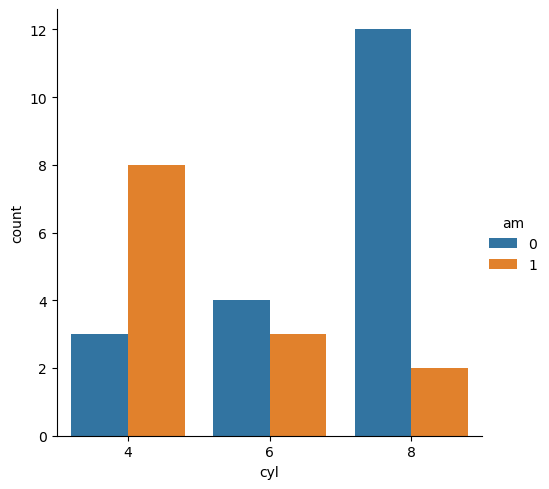

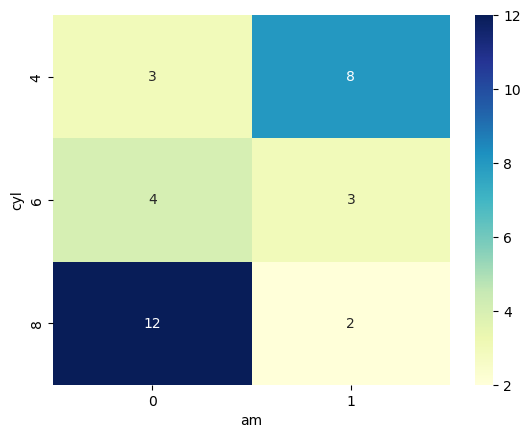

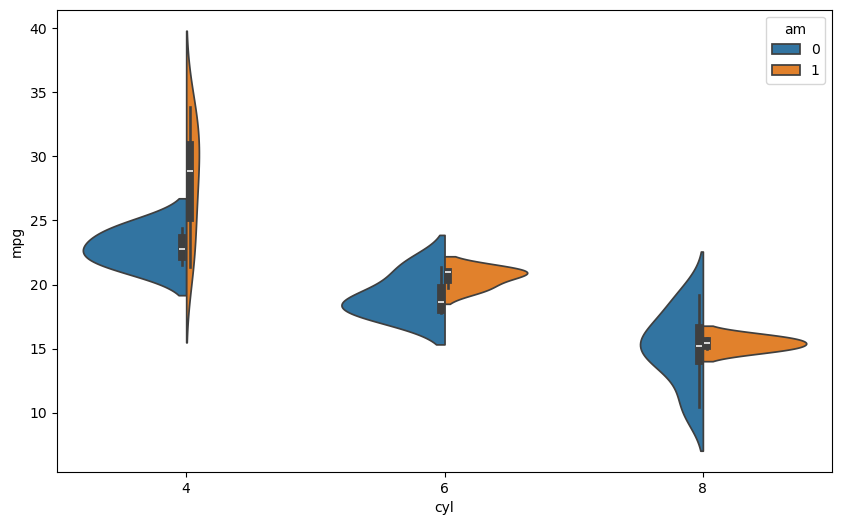

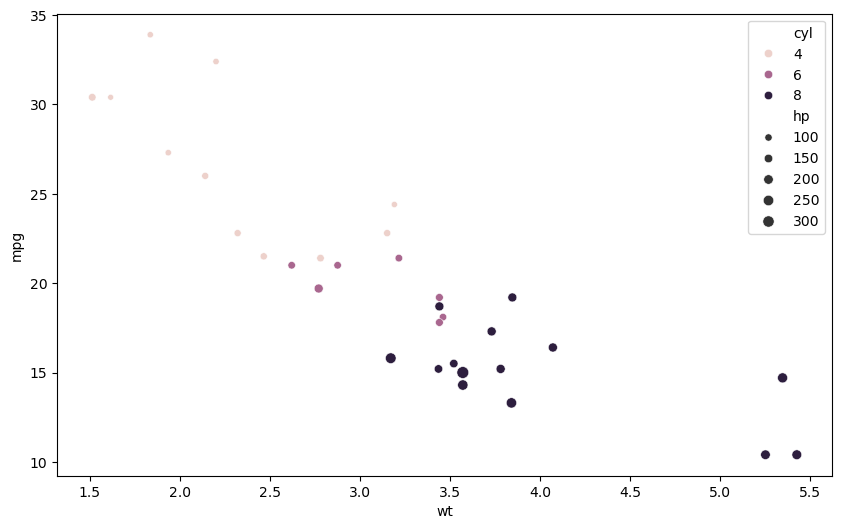

           mpg       cyl      disp        hp      drat        wt      qsec  \
mpg   1.000000 -0.852162 -0.847551 -0.776168  0.681172 -0.867659  0.418684   
cyl  -0.852162  1.000000  0.902033  0.832447 -0.699938  0.782496 -0.591242   
disp -0.847551  0.902033  1.000000  0.790949 -0.710214  0.887980 -0.433698   
hp   -0.776168  0.832447  0.790949  1.000000 -0.448759  0.658748 -0.708223   
drat  0.681172 -0.699938 -0.710214 -0.448759  1.000000 -0.712441  0.091205   
wt   -0.867659  0.782496  0.887980  0.658748 -0.712441  1.000000 -0.174716   
qsec  0.418684 -0.591242 -0.433698 -0.708223  0.091205 -0.174716  1.000000   
vs    0.664039 -0.810812 -0.710416 -0.723097  0.440278 -0.554916  0.744535   
am    0.599832 -0.522607 -0.591227 -0.243204  0.712711 -0.692495 -0.229861   
gear  0.480285 -0.492687 -0.555569 -0.125704  0.699610 -0.583287 -0.212682   
carb -0.550925  0.526988  0.394977  0.749812 -0.090790  0.427606 -0.656249   

            vs        am      gear      carb  
mpg   0.664039  

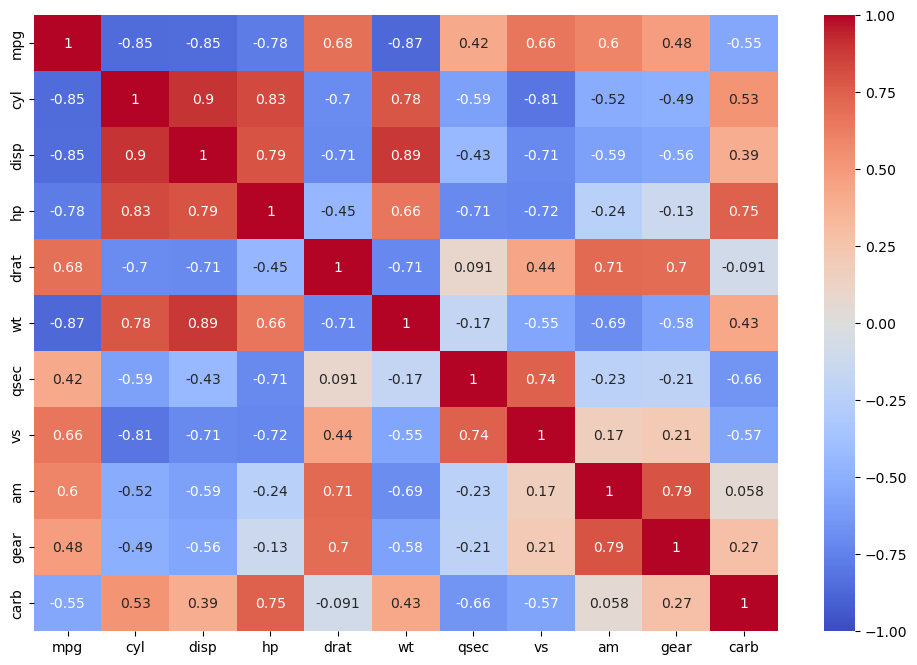

In [2]:
import sys 
!{sys.executable} -m pip install pandas seaborn matplotlib numpy 
import os 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
print(os.getcwd()) 
df = pd.read_csv("MTCARS.csv") 
print(df.head()) 
print(df.tail()) 
df.info() 
print(df.isnull().sum()) 
print(df.describe()) 
print(df.shape) 
df_cleaned = df.drop(['model'], axis=1) 
df_cleaned["mpg"] = df_cleaned["mpg"].fillna(df_cleaned.groupby("cyl")["mpg"].transform("mean")) 
plt.figure(figsize=(8, 5)) 
sns.countplot(x="cyl", data=df_cleaned) 
plt.show() 
plt.figure(figsize=(8, 5)) 
plt.hist(df_cleaned['mpg'], bins=10, color='skyblue', edgecolor='black') 
plt.show() 
plt.figure(figsize=(8, 5)) 
sns.boxplot(x=df_cleaned['hp']) 
plt.show() 
sns.catplot(x="cyl", hue="am", kind="count", data=df_cleaned) 
plt.show() 
group1 = df_cleaned.groupby(['cyl', 'am']) 
cyl_am_table = group1.size().unstack() 
sns.heatmap(cyl_am_table, annot=True, fmt="d", cmap="YlGnBu") 
plt.show() 
plt.figure(figsize=(10, 6)) 
sns.violinplot(x="cyl", y="mpg", hue="am", data=df_cleaned, split=True) 
plt.show() 
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='wt', y='mpg', hue='cyl', size='hp', data=df_cleaned) 
plt.show() 
mtcars_corr = df_cleaned.corr(method="pearson") 
print(mtcars_corr) 
plt.figure(figsize=(12, 8)) 
sns.heatmap(mtcars_corr, annot=True, vmax=1, vmin=-1, cmap='coolwarm') 
plt.show() 